# Part II: Investigating the Vanishing Gradient Problem
Experimentally demonstrate the vanishing gradient problem in deep CNNs and understand how ResNet's architecture mitigates it. Also, explore other key CNN concepts through additional experiments.

In [ ]:
import torch
from torchvision.datasets import ImageFolder
from torchvision import transforms as T
from torch.utils.data import DataLoader, Subset , Dataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.cm as colormaps
import numpy as np

import torch.nn as nn
import torch.optim as optim

import json
import time
import copy

from tqdm import tqdm

from sklearn.metrics import precision_score, recall_score, f1_score , accuracy_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve , auc
from sklearn.preprocessing import label_binarize

from torchsummary import summary

import random
import builtins
device = torch.device("mps" if torch.mps.is_available() else "cpu")
device

device(type='mps')

In [39]:
seed = 18
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

In [ ]:

transform = T.Compose([
    T.Resize((224, 224), antialias=True),
    T.ToTensor(),
    T.ConvertImageDtype(torch.float32),
])

dataset = ImageFolder(root='./cnn_dataset', transform=transform)

labels = dataset.targets

indices = [i for i in range(len(dataset))]
train_indices, test_indices = train_test_split(indices, test_size=0.1, stratify=labels)
train_indices, val_indices = train_test_split(train_indices, test_size=0.11, stratify=np.array(labels)[train_indices])
train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)
test_dataset = Subset(dataset, test_indices)

In [41]:
augmentation = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224), antialias=True), 
    T.RandomRotation(degrees=(0, 90)),
    T.RandomHorizontalFlip(p=0.3),
    T.ColorJitter(brightness=0.5, hue=0.1),
    T.ToTensor(),  
    T.ConvertImageDtype(torch.float32),   
])

In [42]:
class AugmentedDataset(Dataset):
    def __init__(self, original_dataset, transform, augment_factor=1):
        self.dataset = original_dataset
        self.transform = transform
        self.augment_factor = augment_factor  # How many times to augment each sample

    def __len__(self):
        return len(self.dataset) * self.augment_factor  

    def __getitem__(self, idx):
        original_idx = idx % len(self.dataset) 
        img, label = self.dataset[original_idx]
        img = self.transform(img)  
        return img, label

In [43]:
original_dataset = copy.deepcopy(dataset) 
augment_factor = 3  
augmented_dataset = AugmentedDataset(original_dataset, augmentation, augment_factor=augment_factor)

train_indices = list(range(len(augmented_dataset) // 3)) 
augmented_train_dataset = Subset(augmented_dataset, train_indices)

In [44]:
print("Original dataset size:", len(original_dataset))
print("Augmented dataset size:", len(augmented_dataset)) 
print("Subset size:", len(augmented_train_dataset))

Original dataset size: 30000
Augmented dataset size: 90000
Subset size: 30000


## Step 1: Create a deeper version of your VGG-16 network (VGG-Deep)

In [45]:
class DeepVGG(nn.Module):
    def __init__(self, num_classes):
        super(DeepVGG, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=False),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=False),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=False),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=False),
            nn.Conv2d(256, 256, kernel_size=1),
            nn.ReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=False),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=False),
            nn.Conv2d(512, 512, kernel_size=1),
            nn.ReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer5 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=False),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=False),
            nn.Conv2d(512, 512, kernel_size=1),
            nn.ReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer6 = nn.Sequential(
            nn.Conv2d(512, 640, kernel_size=3, padding=1),
            nn.ReLU(inplace=False),
            nn.Conv2d(640, 640, kernel_size=3, padding=1),
            nn.ReLU(inplace=False),
            nn.Conv2d(640, 640, kernel_size=3, padding=1),
            nn.ReLU(inplace=False),
            nn.Conv2d(640, 640, kernel_size=1),
            nn.ReLU(inplace=False),
        )
        self.fc = nn.Sequential(
            nn.Linear(640 * 7 * 7, 4096),
            nn.ReLU(inplace=False),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=False),
            nn.Linear(4096, num_classes)
        )

        #self.init_weights()

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.layer6(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

    def init_weights(self):
        for module in self.modules():
            if not isinstance(module, nn.Conv2d) and not isinstance(module, nn.Linear):
                continue
            nn.init.xavier_uniform_(module.weight)
            #nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')

In [46]:
#device = torch.device("mps" if torch.mps.is_available() else "cpu")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_deep = DeepVGG(num_classes=3).to(device)
summary(vgg_deep, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

## Step 2: Training VGG-Deep

In [47]:
def train_one_epoch(model , train_loader  , optimizer , loss_function   ):
    global n_iteration
    model.train()

    epoch_loss = 0.0
    correct_pred = 0
    total_pred = 0


    for i , (images , labels) in tqdm(enumerate(train_loader)):
        n_iteration += 1
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        #print( outputs.shape , labels.shape)
        loss = loss_function(outputs , labels)

        loss.backward()
        optimizer.step()


        epoch_loss += loss.item()
        _,pred = torch.max(outputs , 1)
        correct_pred += (pred == labels).sum().item()
        total_pred += labels.size(0)


    optimizer.step()
    optimizer.zero_grad()


    # Average loss
    avg_train_loss = epoch_loss/len(train_loader)
    train_acc = correct_pred / total_pred

    print(f"Training loss { avg_train_loss} | accuracy {train_acc} ")

    return avg_train_loss,train_acc

In [48]:
def val(model , loader , loss_function ):
    model.eval()

    curr_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(loader):
            images, labels = images.to(device), labels.to(device)

            output = model(images)
            #print(output.shape , labels.shape)
            batch_loss = loss_function(output , labels)

            curr_loss += batch_loss.item()
            _,pred = torch.max(output , 1)

            correct += (pred == labels).sum().item()
            total += labels.size(0)


    epoch_loss = curr_loss/len(loader)
    acc = correct/total

    print(f"validation loss { epoch_loss} | accuracy {acc} ")

    return epoch_loss , acc


#eval(model , val_loader , criterion , device)

In [49]:
def train(model , train_loader , val_loader , epochs , optimizer , loss_function , training_details , best_model_path=None, scheduler=None):
    train_loss_list = []
    val_loss_list = []
    val_acc_list = []
    train_acc_list = []
    lr_reduction = 0

    best_val_acc = 0.0

    start_time = time.time()

    for epoch in range(epochs):
        print("\n\n\n********************************************")
        print(f"Epoch :{epoch + 1}")
        print(f"Learning Rate {optimizer.param_groups[0]['lr']}")
        train_loss,train_acc = train_one_epoch(
                                        model=model,
                                        train_loader=train_loader,
                                        optimizer=optimizer,
                                        loss_function=loss_function,
                                        )


        val_loss, val_acc = val(
                                model=model,
                                loader=val_loader,
                                loss_function=loss_function
                            )
        if scheduler is not None:
            prev_lr = optimizer.param_groups[0]['lr']
            scheduler.step(val_acc)
            current_lr = optimizer.param_groups[0]['lr']
            if current_lr < prev_lr:
                lr_reduction += 1

        print(f"Learning Rate {optimizer.param_groups[0]['lr']}")

        if best_model_path is not None and val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)  # Save best model
            print(f"New best model saved at epoch {epoch+1} with validation accuracy {val_acc:.4f}")

        train_loss_list.append(train_loss)
        val_loss_list.append(val_loss)
        val_acc_list.append(val_acc)
        train_acc_list.append(train_acc)

    end_time = time.time()

    print(f"\nExecution Time: {(end_time-start_time):.6f} seconds")

    training_details["train_acc"].extend(train_acc_list)
    training_details["val_acc"].extend(val_acc_list)
    training_details["train_loss"].extend(train_loss_list)
    training_details["val_loss"].extend(val_loss_list)

In [50]:
# gradient hook function
def gradient_hook(module, grad_input, grad_output):
    # keep track of the norm for every 10th iteration
    global grad_norms
    global n_iteration
    if n_iteration % 10 != 0:
        return
    # grad_output is a tuple, and we want the gradient w.r.t. weights
    grad_norm = grad_output[0].norm(p=2).item()
    # Store grad_norm (e.g., in a list or dictionary)
    # You'll need a way to associate this norm with the layer and iteration
    layer_id = builtins.id(module)
    if layer_id not in grad_norms.keys():
        grad_norms[layer_id] = []
    grad_norms[layer_id].append((n_iteration, grad_norm))



In [51]:
# reigster the hook for every Conv2d layer in the model
for layer in vgg_deep.modules():
    if isinstance(layer, nn.Conv2d):
        layer.register_full_backward_hook(gradient_hook)

In [53]:
train_loader = DataLoader(augmented_train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [54]:
num_epochs = 10
learning_rate = 0.01

#vggdeep = DeepVGG(num_classes=3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(vgg_deep.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=1)

In [55]:
grad_norms = {}
n_iteration = 0

training_details = {}
training_details["train_acc"] = []
training_details["val_acc"] = []
training_details["train_loss"] = []
training_details["val_loss"] = []

In [ ]:


train(
    model=vgg_deep,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=num_epochs,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=training_details,
    scheduler = scheduler
    )

with open('training_details_vggdeep.txt', 'w') as file:
    json.dump(training_details, file)




********************************************
Epoch :1
Learning Rate 0.01


469it [05:29,  1.42it/s]


Training loss 1.0986769707726518 | accuracy 0.3317 


100%|██████████| 12/12 [00:10<00:00,  1.20it/s]


validation loss 1.0986093481381733 | accuracy 0.3333333333333333 
Learning Rate 0.01



********************************************
Epoch :2
Learning Rate 0.01


...

validation loss 1.0986048181851704 | accuracy 0.3333333333333333 
Learning Rate 1.0000000000000002e-06



********************************************
Epoch :10
Learning Rate 1.0000000000000002e-06


469it [05:27,  1.43it/s]


Training loss 1.09861857423396 | accuracy 0.3333333333333333 


100%|██████████| 12/12 [00:11<00:00,  1.07it/s]

validation loss 1.0986048181851704 | accuracy 0.3333333333333333 
Learning Rate 1.0000000000000002e-06

Execution Time: 3485.167907 seconds


## Step 3: Gradient analysis

- Track the average L2 norm of the gradients in each convolutional layer using PyTorch hooks.

In [ ]:
avg_grad_norms = {}
for i, (_, norms) in enumerate(grad_norms.items()):
    sum_norms = {}
    for iteration, value in norms:
        if iteration not in sum_norms.keys():
            sum_norms[iteration] = []
        sum_norms[iteration].append(value)
    avg_grad_norms[f"Layer_{len(grad_norms)-i}"] = [np.mean(values) for iteration, values in sum_norms.items()]

- Create a plot showing the average gradient norm for each convolutional layer over time.

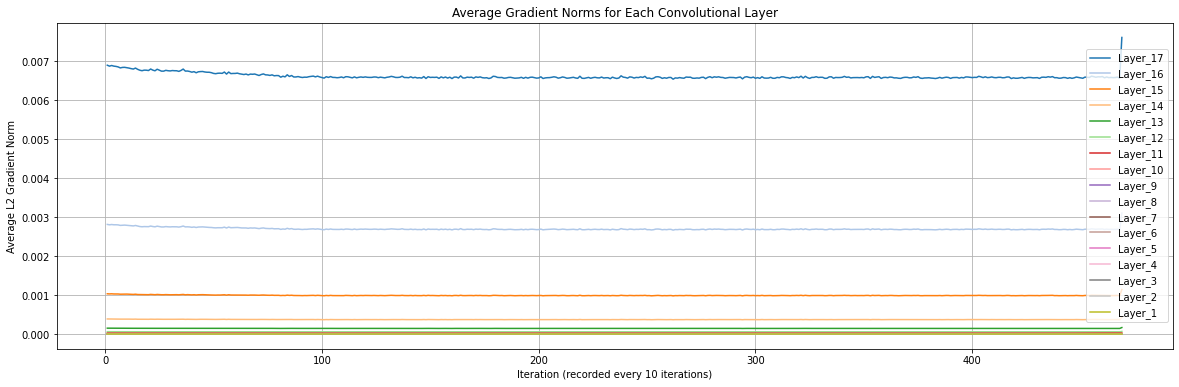

In [ ]:
plt.figure(figsize=(20, 6))
iterations = list(range(1, n_iteration//10 +1))

colors = colormaps.get_cmap('tab20')

for i, (id, norms) in enumerate(avg_grad_norms.items()):
    plt.plot(iterations, norms, label=id, color = colors(i))

plt.title('Average Gradient Norms for Each Convolutional Layer')
plt.xlabel('Iteration (recorded every 10 iterations)')
plt.ylabel('Average L2 Gradient Norm')
plt.legend(loc="right")
plt.grid()
plt.show()


- Create a separate plot showing the gradient norms for a subset of layers.

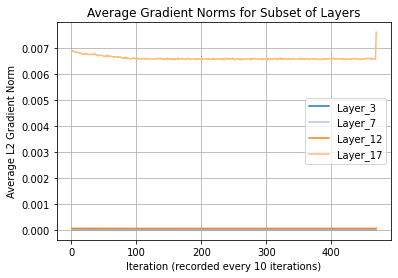

In [ ]:
subset_keys = ["Layer_3", "Layer_7", "Layer_12", "Layer_17"]
subset_vals = [avg_grad_norms.get(key) for key in subset_keys]
for i, norms in enumerate(subset_vals):
    plt.plot(iterations, norms, label=subset_keys[i], color = colors(i))

plt.title('Average Gradient Norms for Subset of Layers')
plt.xlabel('Iteration (recorded every 10 iterations)')
plt.ylabel('Average L2 Gradient Norm')
plt.legend(loc="right")
plt.grid()
plt.show()

## Step 4: Comparison with VGG-16 and ResNet-18

- Compare the training curves (loss and accuracy vs. epoch) of VGG-Deep, VGG-16, and ResNet-18.

In [ ]:
def plot_extended(type, list_dic):
    colors = colormaps.get_cmap('tab20')
    epochs = max(len(list) for list in list_dic.values())
    plt.figure(figsize=(20, 6))
    for i, (model, loss) in enumerate(list_dic.items()):
        if(len(loss) < epochs):
            loss_extended = loss+[loss[-1] for _ in range(epochs-len(loss))]
            plt.plot(range(1, len(loss)+1), loss, label=f"{model} {type}", marker='o', color = colors(i*4))
            plt.plot(range(len(loss), epochs+1), loss_extended[len(loss)-1:], '--', label=f"{model} {type} (extended)", color = colors(i*4))
        else:
            plt.plot(range(1, epochs+1), loss, label=f"{model} {type}", marker='o', color = colors(i*4))

    plt.title(f'{list(list_dic.keys())} {type}')
    plt.xlabel('Epochs')
    plt.ylabel(f"{type}")
    plt.legend()
    plt.grid()
    plt.xticks()
    plt.show()

In [ ]:
vgg_deep = training_details
with open("training_details_vgg16_he.txt", "r") as file:
    vgg16_details = json.load(file)
with open("training_details_resnet18_base.txt", "r") as file:
    resnet18_details = json.load(file)

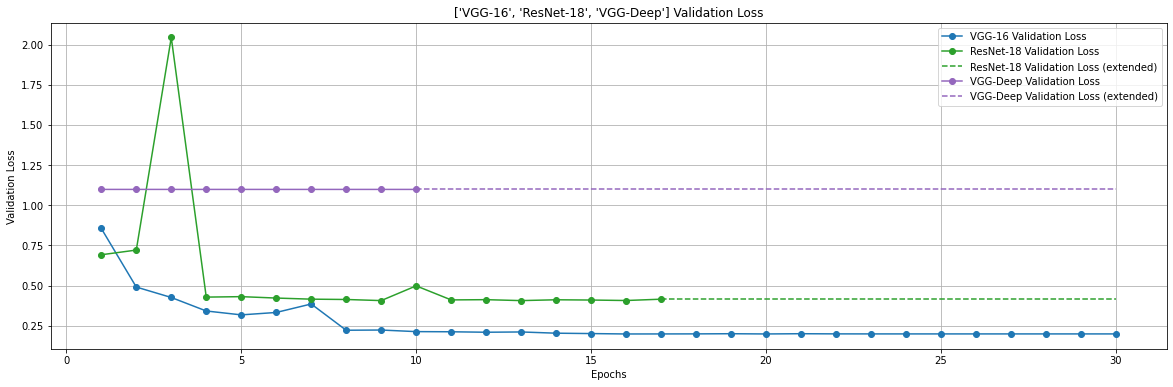

In [ ]:
loss_lists = {"VGG-16": vgg16_details['val_loss'], "ResNet-18": resnet18_details['val_loss'], "VGG-Deep": training_details['val_loss']}
plot_extended(type="Validation Loss", list_dic = loss_lists)

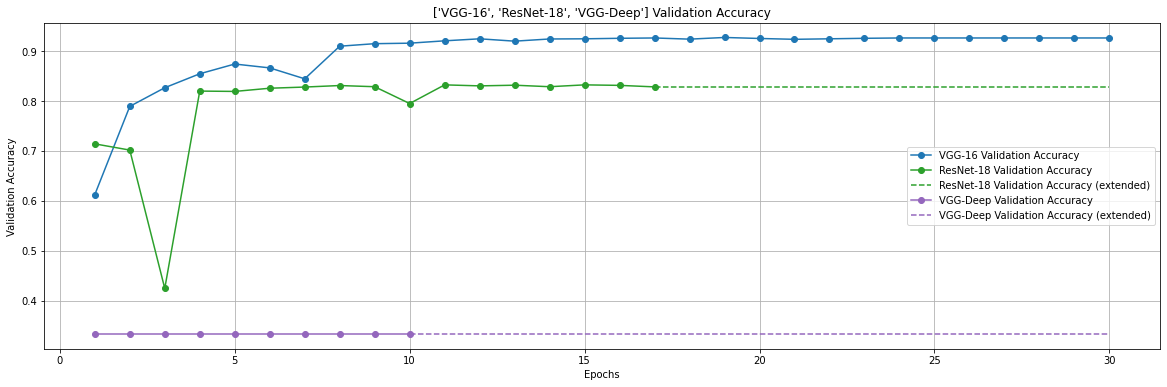

In [ ]:
acc_lists = {"VGG-16": vgg16_details['train_acc'], "ResNet-18": resnet18_details['train_acc'], "VGG-Deep": training_details['train_acc']}
plot_extended(type="Validation Accuracy", list_dic = acc_lists)

How ResNet’s residual connections impact the gradient flow compared to VGG-Deep </br>
<span style='color:green'>
Due to Residual connection in Resnet there is direct path  for gradient to flow throught the network and helps to remove the vansishing gradient for deep network with large number of layers. where in VGG as network depth increases it faces issue of vanishing gradient and make difficult to train very deep Network.
<br>
Residual connection is key factor in training of very deep neural network.
</span>

## Step 5: Investigate and analyze more setups

In [ ]:
def evaluate(model , test_loader , loss_function ):
    y_true = []
    y_pred = []

    curr_loss = 0

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            batch_loss = loss_function(outputs , labels)
            curr_loss += batch_loss.item()
            _, predicted = torch.max(outputs, 1)
            y_pred.extend(list(predicted.cpu().numpy()))
            y_true.extend(list(labels.cpu().numpy()))

        epoch_loss = curr_loss/len(test_loader)
        acc = accuracy_score(y_true,y_pred)
        precision = precision_score(y_true, y_pred, average='weighted')
        recall = recall_score(y_true, y_pred, average='weighted')
        f1 = f1_score(y_true, y_pred, average='weighted')

        print(f"Loss : {epoch_loss} | Acc : {acc}")
        print(f'Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')

    return y_true , y_pred , epoch_loss , acc

def plot_loss(training_details , test_loss):
    train_loss_list = training_details["train_loss"]
    val_loss_list = training_details["val_loss"]
    #test_loss = test_loss

    plt.figure(figsize=(20, 6))
    epochs = range(1, len(train_loss_list) + 1)
    test_loss_list = [test_loss] * len(epochs)

    plt.plot(epochs, train_loss_list, label='Training Loss', marker='o')
    plt.plot(epochs, val_loss_list, label='Validation Loss', marker='o')
    plt.plot(epochs, test_loss_list, label='Test Loss', color='red', linestyle='--')

    plt.title('Training, Validation, and Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')


    plt.legend()
    plt.grid()
    plt.xticks()
    plt.show()

def plot_accuracy(training_details , test_acc):
    train_acc_list = training_details["train_acc"]
    val_acc_list = training_details["val_acc"]
    test_accuracy = test_acc

    plt.figure(figsize=(20, 6))
    test_acc_list = [test_accuracy] * len(train_acc_list)
    epochs = range(1, len(train_acc_list) + 1)

    plt.plot(epochs, train_acc_list, label='Training Accuracy', marker='o')
    plt.plot(epochs, val_acc_list, label='Validation Accuracy', marker='o')
    plt.plot(epochs, test_acc_list, label='Test Accuracy', linestyle='--')

    plt.title('Training, Validation, and Test Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')

    plt.legend()
    plt.grid()
    plt.xticks()
    plt.show()

### Experiment 1: Kernel size


*   size 3x3
*   size 5x5



In [ ]:
# use a subset of the data
subset_transform = T.Compose([
    T.Resize((224, 224), antialias=True),
    T.ToTensor(),
    T.ConvertImageDtype(torch.float32),
])


subset_dataset = ImageFolder(root='./cnn_dataset', transform=subset_transform)
# subset_dataset = ImageFolder(root='/content/drive/My Drive/cnn_dataset', transform=subset_transform)
subset_labels = subset_dataset.targets

subset_indices = [i for i in range(len(subset_dataset))]
subset_indices, rest_indices = train_test_split(subset_indices, test_size=0.875, stratify=subset_labels)
subset_train_indices, subset_test_indices = train_test_split(subset_indices, test_size=0.1, stratify=np.array(subset_labels)[subset_indices])
subset_train_indices, subset_val_indices = train_test_split(subset_train_indices, test_size=0.11, stratify=np.array(subset_labels)[subset_train_indices])
subset_train_dataset = Subset(subset_dataset, subset_train_indices)
subset_val_dataset = Subset(subset_dataset, subset_val_indices)
subset_test_dataset = Subset(subset_dataset, subset_test_indices)

subset_train_loader = DataLoader(subset_train_dataset, batch_size=32, shuffle=True)
subset_val_loader = DataLoader(subset_val_dataset, batch_size=32, shuffle=False)
subset_test_loader = DataLoader(subset_test_dataset, batch_size=32, shuffle=False)

In [ ]:
class VGGKernel3(nn.Module):
    def __init__(self, num_classes):
        super(VGGKernel3, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=False),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=False),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 56 * 56, 256),
            nn.ReLU(inplace=False),
            nn.Linear(256, 256),
            nn.ReLU(inplace=False),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        #print(x.shape)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
model_kernel_3 = VGGKernel3(num_classes=3).to(device)
summary(model_kernel_3, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Linear-11                  [-1, 256]     102,760,704
             ReLU-12                  [-1, 256]               0
           Linear-13                  [-1, 256]          65,792
             ReLU-14                  [

In [ ]:
num_epochs = 100
learning_rate = 0.1
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_kernel_3.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=2)

kernel3_details = {}
kernel3_details["train_acc"] = []
kernel3_details["val_acc"] = []
kernel3_details["train_loss"] = []
kernel3_details["val_loss"] = []

train(
    model=model_kernel_3,
    train_loader=subset_train_loader,
    val_loader=subset_val_loader,
    epochs=num_epochs,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=kernel3_details,
    best_model_path="best_model_kernel3.pth",
    scheduler = scheduler
    )

with open('training_details_kernel3.txt', 'w') as file:
# with open('/content/drive/My Drive/training_details_kernel3.txt', 'w') as file:
    json.dump(kernel3_details, file)




********************************************
Epoch :1
Learning Rate 0.1


94it [00:12,  7.76it/s]


Training loss 1.0823136276387153 | accuracy 0.40626040626040627 


100%|██████████| 12/12 [00:01<00:00, 11.35it/s]


validation loss 1.7520033915837605 | accuracy 0.3817204301075269 
Learning Rate 0.1
New best model saved at epoch 1 with validation accuracy 0.3817



********************************************
Epoch :2
Learning Rate 0.1


...

94it [00:12,  7.75it/s]


Training loss 0.47403218692287485 | accuracy 0.8081918081918081 


100%|██████████| 12/12 [00:01<00:00, 10.84it/s]


validation loss 0.598159929116567 | accuracy 0.75 
Learning Rate 1.0000000000000005e-08



********************************************
Epoch :69
Learning Rate 1.0000000000000005e-08


25it [00:03,  8.25it/s]IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [ ]:
class VGGKernel5(nn.Module):
    def __init__(self, num_classes):
        super(VGGKernel5, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5, padding=1),
            nn.ReLU(inplace=False),
            nn.Conv2d(64, 64, kernel_size=5, padding=1),
            nn.ReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=5, padding=1),
            nn.ReLU(inplace=False),
            nn.Conv2d(128, 128, kernel_size=5, padding=1),
            nn.ReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 53 * 53, 256),
            nn.ReLU(inplace=False),
            nn.Linear(256, 256),
            nn.ReLU(inplace=False),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        #print(x.shape)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
model_kernel_5 = VGGKernel5(num_classes=3).to(device)
summary(model_kernel_5, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 222, 222]           4,864
              ReLU-2         [-1, 64, 222, 222]               0
            Conv2d-3         [-1, 64, 220, 220]         102,464
              ReLU-4         [-1, 64, 220, 220]               0
         MaxPool2d-5         [-1, 64, 110, 110]               0
            Conv2d-6        [-1, 128, 108, 108]         204,928
              ReLU-7        [-1, 128, 108, 108]               0
            Conv2d-8        [-1, 128, 106, 106]         409,728
              ReLU-9        [-1, 128, 106, 106]               0
        MaxPool2d-10          [-1, 128, 53, 53]               0
           Linear-11                  [-1, 256]      92,045,568
             ReLU-12                  [-1, 256]               0
           Linear-13                  [-1, 256]          65,792
             ReLU-14                  [

In [ ]:
num_epochs = 40
learning_rate = 0.1
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_kernel_5.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=2)

kernel5_details = {}
kernel5_details["train_acc"] = []
kernel5_details["val_acc"] = []
kernel5_details["train_loss"] = []
kernel5_details["val_loss"] = []

train(
    model=model_kernel_5,
    train_loader=subset_train_loader,
    val_loader=subset_val_loader,
    epochs=num_epochs,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=kernel5_details,
    best_model_path="best_model_kernel5.pth",
    scheduler = scheduler
    )

with open('training_details_kernel5.txt', 'w') as file:
# with open('/content/drive/My Drive/training_details_kernel5.txt', 'w') as file:
    json.dump(kernel5_details, file)




********************************************
Epoch :1
Learning Rate 0.1


94it [00:14,  6.61it/s]


Training loss 1.09563439957639 | accuracy 0.36363636363636365 


100%|██████████| 12/12 [00:01<00:00,  7.88it/s]


validation loss 1.093884785970052 | accuracy 0.34946236559139787 
Learning Rate 0.1
New best model saved at epoch 1 with validation accuracy 0.3495



********************************************
Epoch :2
Learning Rate 0.1


...

validation loss 1.0636748770872753 | accuracy 0.40053763440860213 
Learning Rate 1.0000000000000005e-08



********************************************
Epoch :40
Learning Rate 1.0000000000000005e-08


94it [00:12,  7.24it/s]


Training loss 1.0667086991857975 | accuracy 0.4012654012654013 


100%|██████████| 12/12 [00:01<00:00,  9.03it/s]

validation loss 1.0636748274167378 | accuracy 0.40053763440860213 
Learning Rate 1.0000000000000005e-08

Execution Time: 562.635948 seconds


In [ ]:
class VGGKernel7(nn.Module):
    def __init__(self, num_classes):
        super(VGGKernel7, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, padding=1),
            nn.ReLU(inplace=False),
            nn.Conv2d(64, 64, kernel_size=7, padding=1),
            nn.ReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=7, padding=1),
            nn.ReLU(inplace=False),
            nn.Conv2d(128, 128, kernel_size=7, padding=1),
            nn.ReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 50 * 50, 256),
            nn.ReLU(inplace=False),
            nn.Linear(256, 256),
            nn.ReLU(inplace=False),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
model_kernel_7 = VGGKernel7(num_classes=3).to(device)
summary(model_kernel_7, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 220, 220]           9,472
              ReLU-2         [-1, 64, 220, 220]               0
            Conv2d-3         [-1, 64, 216, 216]         200,768
              ReLU-4         [-1, 64, 216, 216]               0
         MaxPool2d-5         [-1, 64, 108, 108]               0
            Conv2d-6        [-1, 128, 104, 104]         401,536
              ReLU-7        [-1, 128, 104, 104]               0
            Conv2d-8        [-1, 128, 100, 100]         802,944
              ReLU-9        [-1, 128, 100, 100]               0
        MaxPool2d-10          [-1, 128, 50, 50]               0
           Linear-11                  [-1, 256]      81,920,256
             ReLU-12                  [-1, 256]               0
           Linear-13                  [-1, 256]          65,792
             ReLU-14                  [

In [ ]:
num_epochs = 40
learning_rate = 0.1
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_kernel_7.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=2)

kernel7_details = {}
kernel7_details["train_acc"] = []
kernel7_details["val_acc"] = []
kernel7_details["train_loss"] = []
kernel7_details["val_loss"] = []

train(
    model=model_kernel_7,
    train_loader=subset_train_loader,
    val_loader=subset_val_loader,
    epochs=num_epochs,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=kernel7_details,
    best_model_path="best_model_kernel7.pth",
    scheduler = scheduler
    )

with open('training_details_kernel7.txt', 'w') as file:
# with open('/content/drive/My Drive/training_details_kernel7.txt', 'w') as file:
    json.dump(kernel7_details, file)




********************************************
Epoch :1
Learning Rate 0.1


94it [00:13,  6.81it/s]


Training loss 1.2184507447354338 | accuracy 0.356976356976357 


100%|██████████| 12/12 [00:01<00:00,  8.43it/s]


validation loss 1.100124677022298 | accuracy 0.3333333333333333 
Learning Rate 0.1
New best model saved at epoch 1 with validation accuracy 0.3333



********************************************
Epoch :2
Learning Rate 0.1


...

validation loss 0.6030807718634605 | accuracy 0.7661290322580645 
Learning Rate 1.0000000000000005e-08



********************************************
Epoch :40
Learning Rate 1.0000000000000005e-08


94it [00:13,  6.82it/s]


Training loss 0.4004735524984116 | accuracy 0.8398268398268398 


100%|██████████| 12/12 [00:01<00:00,  8.45it/s]

validation loss 0.603080578148365 | accuracy 0.7661290322580645 
Learning Rate 1.0000000000000005e-08

Execution Time: 631.538505 seconds


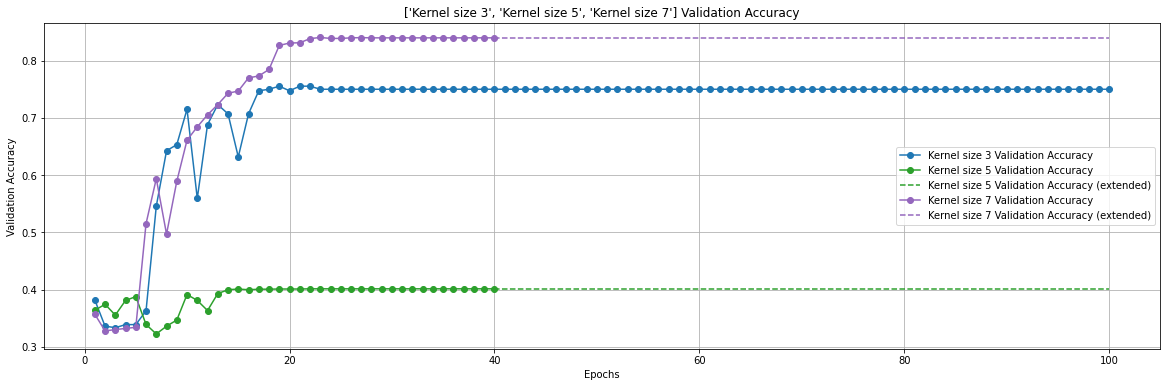

In [ ]:
kernel_lists = {"Kernel size 3": kernel3_details['val_acc'], "Kernel size 5": kernel5_details['train_acc'], "Kernel size 7": kernel7_details['train_acc']}
plot_extended(type="Validation Accuracy", list_dic = kernel_lists)

<span style='color:green'>
Considering the results highest accuracy with 7x7 kernel. it was able to extract all the major features given the size of whole model, on the other hand 3x3 kernal better at capturing fine details but may be it was not able to capture whole bigger picture due to small stacking of convo layer. 5x5 kernal is not appropriate choice considering the results.
</span>

### Experiment 2: Max Pooling vs. Average Pooling

In [ ]:
# Small dataset for test
"""
s_train_dataset = Subset(augmented_train_dataset, list(range(320)))
s_val_dataset = Subset(val_dataset, list(range(320)))
num_epochs = 2

train_loader = DataLoader(s_train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(s_val_dataset, batch_size=32, shuffle=False)
"""

'\ns_train_dataset = Subset(augmented_train_dataset, list(range(320)))\ns_val_dataset = Subset(val_dataset, list(range(320)))\nnum_epochs = 2\n\ntrain_loader = DataLoader(s_train_dataset, batch_size=32, shuffle=True)\nval_loader = DataLoader(s_val_dataset, batch_size=32, shuffle=False)\n'

In [ ]:
class VGGMaxPooling(nn.Module):
    def __init__(self, num_classes):
        super(VGGMaxPooling, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5, padding=1),
            nn.ReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 64, kernel_size=5, padding=1),
            nn.ReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=5, padding=1),
            nn.ReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 128, kernel_size=5, padding=1),
            nn.ReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(inplace=False),
            nn.Linear(256, 256),
            nn.ReLU(inplace=False),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
model_max_pooling = VGGMaxPooling(num_classes=3).to(device)
summary(model_max_pooling, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 222, 222]           4,864
              ReLU-2         [-1, 64, 222, 222]               0
         MaxPool2d-3         [-1, 64, 111, 111]               0
            Conv2d-4         [-1, 64, 109, 109]         102,464
              ReLU-5         [-1, 64, 109, 109]               0
         MaxPool2d-6           [-1, 64, 54, 54]               0
            Conv2d-7          [-1, 128, 52, 52]         204,928
              ReLU-8          [-1, 128, 52, 52]               0
         MaxPool2d-9          [-1, 128, 26, 26]               0
           Conv2d-10          [-1, 128, 24, 24]         409,728
             ReLU-11          [-1, 128, 24, 24]               0
        MaxPool2d-12          [-1, 128, 12, 12]               0
           Linear-13                  [-1, 256]       4,718,848
             ReLU-14                  [

In [ ]:
num_epochs = 40
learning_rate = 0.1
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_max_pooling.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=2)

maxpool_details = {}
maxpool_details["train_acc"] = []
maxpool_details["val_acc"] = []
maxpool_details["train_loss"] = []
maxpool_details["val_loss"] = []

train(
    model=model_max_pooling,
    train_loader=subset_train_loader,
    val_loader=subset_val_loader,
    epochs=num_epochs,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=maxpool_details,
    best_model_path="best_model_maxpool.pth",
    scheduler = scheduler
    )

with open('training_details_maxpool.txt', 'w') as file:
# with open('/content/drive/My Drive/training_details_maxpool.txt', 'w') as file:
    json.dump(maxpool_details, file)




********************************************
Epoch :1
Learning Rate 0.1


94it [00:11,  8.47it/s]


Training loss 1.0979273674335885 | accuracy 0.356976356976357 


100%|██████████| 12/12 [00:01<00:00, 10.90it/s]


validation loss 1.0913736919562023 | accuracy 0.34139784946236557 
Learning Rate 0.1
New best model saved at epoch 1 with validation accuracy 0.3414



********************************************
Epoch :2
Learning Rate 0.1


...

validation loss 0.48895219216744107 | accuracy 0.7903225806451613 
Learning Rate 1.0000000000000004e-06



********************************************
Epoch :40
Learning Rate 1.0000000000000004e-06


94it [00:10,  8.94it/s]


Training loss 0.3757950300548939 | accuracy 0.8521478521478522 


100%|██████████| 12/12 [00:01<00:00, 11.41it/s]

validation loss 0.4889581501483917 | accuracy 0.7903225806451613 
Learning Rate 1.0000000000000005e-07

Execution Time: 466.314991 seconds


In [ ]:
class VGGAvgPooling(nn.Module):
    def __init__(self, num_classes):
        super(VGGAvgPooling, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5, padding=1),
            nn.ReLU(inplace=False),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 64, kernel_size=5, padding=1),
            nn.ReLU(inplace=False),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=5, padding=1),
            nn.ReLU(inplace=False),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 128, kernel_size=5, padding=1),
            nn.ReLU(inplace=False),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(inplace=False),
            nn.Linear(256, 256),
            nn.ReLU(inplace=False),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
model_avg_pooling = VGGAvgPooling(num_classes=3).to(device)
summary(model_avg_pooling, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 222, 222]           4,864
              ReLU-2         [-1, 64, 222, 222]               0
         AvgPool2d-3         [-1, 64, 111, 111]               0
            Conv2d-4         [-1, 64, 109, 109]         102,464
              ReLU-5         [-1, 64, 109, 109]               0
         AvgPool2d-6           [-1, 64, 54, 54]               0
            Conv2d-7          [-1, 128, 52, 52]         204,928
              ReLU-8          [-1, 128, 52, 52]               0
         AvgPool2d-9          [-1, 128, 26, 26]               0
           Conv2d-10          [-1, 128, 24, 24]         409,728
             ReLU-11          [-1, 128, 24, 24]               0
        AvgPool2d-12          [-1, 128, 12, 12]               0
           Linear-13                  [-1, 256]       4,718,848
             ReLU-14                  [

In [ ]:
num_epochs = 40
learning_rate = 0.1
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_avg_pooling.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=2)


avgpool_details = {}
avgpool_details["train_acc"] = []
avgpool_details["val_acc"] = []
avgpool_details["train_loss"] = []
avgpool_details["val_loss"] = []

train(
    model=model_avg_pooling,
    train_loader=subset_train_loader,
    val_loader=subset_val_loader,
    epochs=num_epochs,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=avgpool_details,
    best_model_path="best_model_avgpool.pth",
    scheduler = scheduler
    )

with open('training_details_avgpool.txt', 'w') as file:
# with open('/content/drive/My Drive/training_details_avgpool.txt', 'w') as file:
    json.dump(avgpool_details, file)




********************************************
Epoch :1
Learning Rate 0.1


94it [00:10,  8.81it/s]


Training loss 1.0935843085989039 | accuracy 0.3786213786213786 


100%|██████████| 12/12 [00:01<00:00, 11.45it/s]


validation loss 1.1746341685454051 | accuracy 0.3763440860215054 
Learning Rate 0.1
New best model saved at epoch 1 with validation accuracy 0.3763



********************************************
Epoch :2
Learning Rate 0.1


...

validation loss 1.0986264149347942 | accuracy 0.3333333333333333 
Learning Rate 1.0000000000000005e-08



********************************************
Epoch :40
Learning Rate 1.0000000000000005e-08


94it [00:10,  8.92it/s]


Training loss 1.0985758875278717 | accuracy 0.3333333333333333 


100%|██████████| 12/12 [00:01<00:00, 11.48it/s]

validation loss 1.0986264149347942 | accuracy 0.3333333333333333 
Learning Rate 1.0000000000000005e-08

Execution Time: 469.880934 seconds


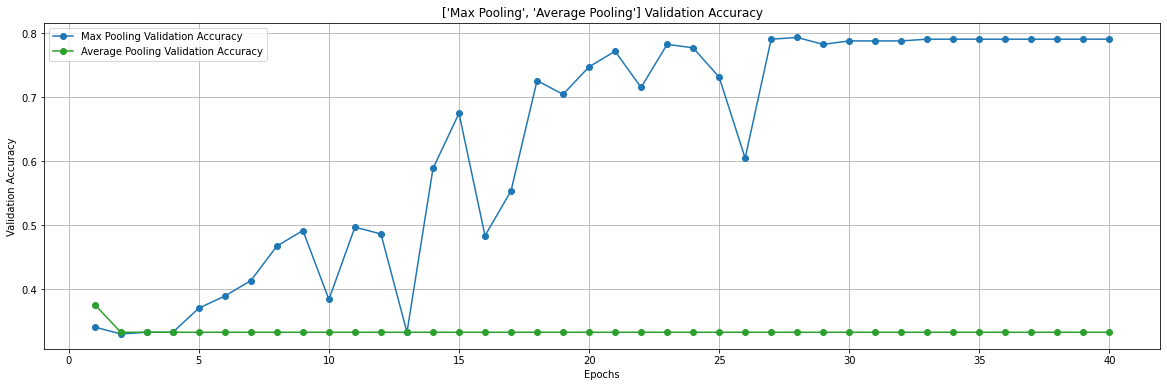

In [ ]:
pooling_lists = {"Max Pooling": maxpool_details['val_acc'], "Average Pooling": avgpool_details['val_acc']}
plot_extended(type="Validation Accuracy", list_dic = pooling_lists)

<span style='color:green'>
Max Pooling is better choice for current experiment and that is indication that capturing the prominent feature is crucial for this task and avg pooling tends to smooth out the feature map. which cause loss in information. This can explain why max pool perform better here.</br>

Max Pooling is better for task where robustness to small variations and noise require, where Avg Pooling can be used where exact location is more important like image segmentation.
</span>

### Experiment 3: Activation functions

In [ ]:
class VGGLeakyReLU(nn.Module):
    def __init__(self, num_classes):
        super(VGGLeakyReLU, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5, padding=1),
            nn.LeakyReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 64, kernel_size=5, padding=1),
            nn.LeakyReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=5, padding=1),
            nn.LeakyReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 128, kernel_size=5, padding=1),
            nn.LeakyReLU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 12 * 12, 256),
            nn.LeakyReLU(inplace=False),
            nn.Linear(256, 256),
            nn.LeakyReLU(inplace=False),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
model_leaky_relu = VGGLeakyReLU(num_classes=3)
summary(model_leaky_relu, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 222, 222]           4,864
         LeakyReLU-2         [-1, 64, 222, 222]               0
         MaxPool2d-3         [-1, 64, 111, 111]               0
            Conv2d-4         [-1, 64, 109, 109]         102,464
         LeakyReLU-5         [-1, 64, 109, 109]               0
         MaxPool2d-6           [-1, 64, 54, 54]               0
            Conv2d-7          [-1, 128, 52, 52]         204,928
         LeakyReLU-8          [-1, 128, 52, 52]               0
         MaxPool2d-9          [-1, 128, 26, 26]               0
           Conv2d-10          [-1, 128, 24, 24]         409,728
        LeakyReLU-11          [-1, 128, 24, 24]               0
        MaxPool2d-12          [-1, 128, 12, 12]               0
           Linear-13                  [-1, 256]       4,718,848
        LeakyReLU-14                  [

In [ ]:
device = 'cpu'

In [ ]:
num_epochs = 40
learning_rate = 0.1
model_leaky_relu = model_leaky_relu.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_leaky_relu.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=2)

leakyrelu_details = {}
leakyrelu_details["train_acc"] = []
leakyrelu_details["val_acc"] = []
leakyrelu_details["train_loss"] = []
leakyrelu_details["val_loss"] = []

train(
    model=model_leaky_relu,
    train_loader=subset_train_loader,
    val_loader=subset_val_loader,
    epochs=num_epochs,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=leakyrelu_details,
    best_model_path="best_model_leakyrelu.pth",
    scheduler = scheduler
    )

with open('training_details_leakyrelu.txt', 'w') as file:
# with open('/content/drive/My Drive/training_details_leakyrelu.txt', 'w') as file:
    json.dump(leakyrelu_details, file)




********************************************
Epoch :1
Learning Rate 0.1


94it [04:23,  2.80s/it]


Training loss 1.092502105743327 | accuracy 0.3663003663003663 


100%|██████████| 12/12 [00:06<00:00,  1.80it/s]


validation loss 1.0956569910049438 | accuracy 0.34408602150537637 
Learning Rate 0.1
New best model saved at epoch 1 with validation accuracy 0.3441



********************************************
Epoch :2
Learning Rate 0.1


...

validation loss 0.9993286927541097 | accuracy 0.510752688172043 
Learning Rate 1.0000000000000005e-08



********************************************
Epoch :40
Learning Rate 1.0000000000000005e-08


94it [05:16,  3.37s/it]


Training loss 0.9393708046446455 | accuracy 0.5567765567765568 


100%|██████████| 12/12 [00:07<00:00,  1.63it/s]

validation loss 0.9993287175893784 | accuracy 0.510752688172043 
Learning Rate 1.0000000000000005e-08

Execution Time: 12793.073504 seconds


In [ ]:
class VGGELU(nn.Module):
    def __init__(self, num_classes):
        super(VGGELU, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5, padding=1),
            nn.ELU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 64, kernel_size=5, padding=1),
            nn.ELU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=5, padding=1),
            nn.ELU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 128, kernel_size=5, padding=1),
            nn.ELU(inplace=False),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 12 * 12, 256),
            nn.ELU(inplace=False),
            nn.Linear(256, 256),
            nn.ELU(inplace=False),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
model_elu = VGGELU(num_classes=3).to(device)
summary(model_elu, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 222, 222]           4,864
               ELU-2         [-1, 64, 222, 222]               0
         MaxPool2d-3         [-1, 64, 111, 111]               0
            Conv2d-4         [-1, 64, 109, 109]         102,464
               ELU-5         [-1, 64, 109, 109]               0
         MaxPool2d-6           [-1, 64, 54, 54]               0
            Conv2d-7          [-1, 128, 52, 52]         204,928
               ELU-8          [-1, 128, 52, 52]               0
         MaxPool2d-9          [-1, 128, 26, 26]               0
           Conv2d-10          [-1, 128, 24, 24]         409,728
              ELU-11          [-1, 128, 24, 24]               0
        MaxPool2d-12          [-1, 128, 12, 12]               0
           Linear-13                  [-1, 256]       4,718,848
              ELU-14                  [

In [ ]:
num_epochs = 40
learning_rate = 0.1
model_leaky_relu = model_leaky_relu.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_leaky_relu.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=2)

elu_details = {}
elu_details["train_acc"] = []
elu_details["val_acc"] = []
elu_details["train_loss"] = []
elu_details["val_loss"] = []

train(
    model=model_elu,
    train_loader=subset_train_loader,
    val_loader=subset_val_loader,
    epochs=num_epochs,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=elu_details,
    best_model_path="best_model_elu.pth",
    scheduler = scheduler
    )

with open('training_details_elu.txt', 'w') as file:
# with open('/content/drive/My Drive/training_details_elu.txt', 'w') as file:
    json.dump(elu_details, file)




********************************************
Epoch :1
Learning Rate 0.1


94it [04:16,  2.73s/it]


Training loss 1.098197230633269 | accuracy 0.3333333333333333 


100%|██████████| 12/12 [00:06<00:00,  1.72it/s]


validation loss 1.0981877744197845 | accuracy 0.3333333333333333 
Learning Rate 0.1
New best model saved at epoch 1 with validation accuracy 0.3333



********************************************
Epoch :2
Learning Rate 0.1


...

validation loss 1.0981877744197845 | accuracy 0.3333333333333333 
Learning Rate 1.0000000000000005e-08



********************************************
Epoch :40
Learning Rate 1.0000000000000005e-08


94it [05:24,  3.45s/it]


Training loss 1.09817166658158 | accuracy 0.3333333333333333 


100%|██████████| 12/12 [00:08<00:00,  1.47it/s]

validation loss 1.0981877744197845 | accuracy 0.3333333333333333 
Learning Rate 1.0000000000000005e-08

Execution Time: 12189.029760 seconds


/var/folders/27/45kf949539vdj0tjjp9nmw380000gn/T/ipykernel_41630/4116968089.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = colormaps.get_cmap('tab20')


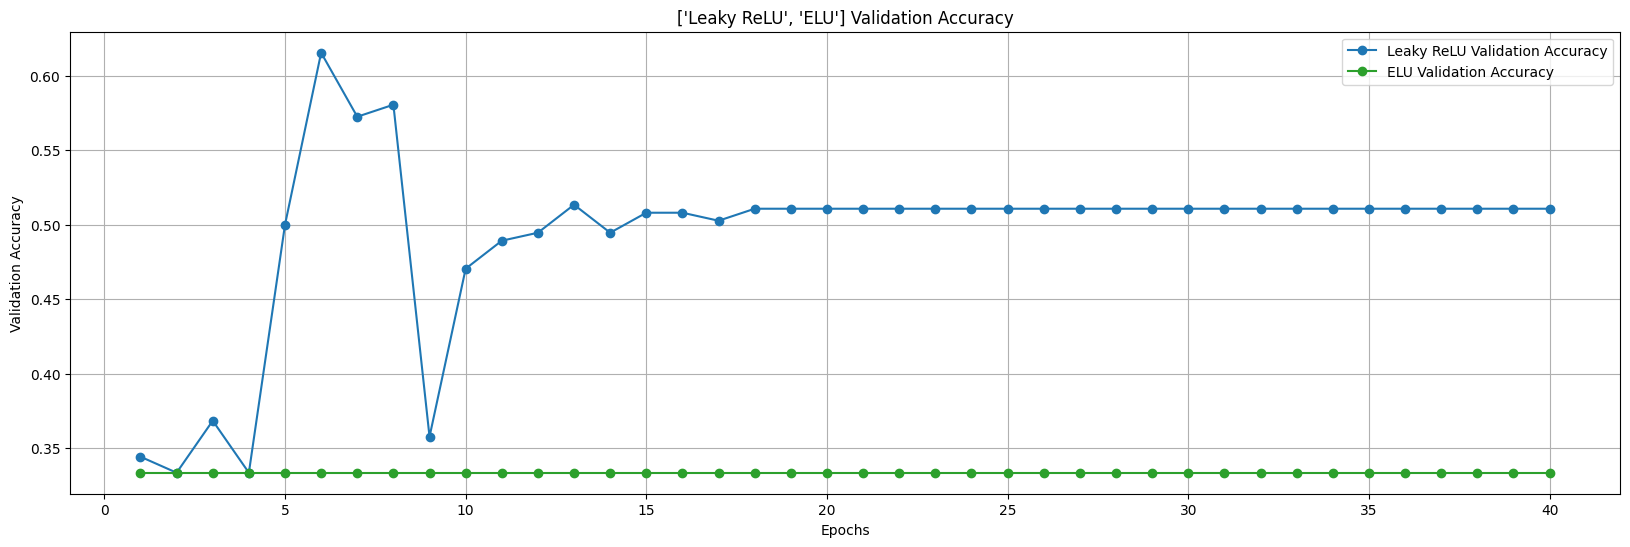

In [ ]:
actfunc_lists = {"Leaky ReLU": leakyrelu_details['val_acc'], "ELU": elu_details['val_acc']}
plot_extended(type="Validation Accuracy", list_dic = actfunc_lists)

<span style='color:green'>
<b>ReLU : </b> Simple, computationally efficient and introduces non-linearity. But has Dying ReLU Problem neurons can "die" during training if they get stuck in the negative side.
</br>
<b> Leaky ReLU : </b> Helps maintain some gradient flow even for negative inputs.
</br>
<b> ELU : </b> Address the Dying ReLU problem by its non-zero gradient for  negative inputs.
</br>
</span>

## Step 6: Analysis and discussion

<img src="output.png" alt="plot" width="1000" height="300">

<span style='color:green'></span>

<span style='color:green'>
The gradient norm plot clearly demonstrates the vanishing gradient problem. As we move deeper into the VGG-Deep network, the gradient norms decrease significantly.
<ul>
    <li>Layer 17 has the highest gradient norm (~0.007), which is already quite small</li>
    <li>Layer 16 has the gradient norm  that is apprximately half of layer 17(~0.003)</li>
    <li>Layer 15 has the dropped again more than half (~0.001)</li>
    <li>Layer below 10 have gradient norm almost zero, indicating that gradient are vanishing </li>
</ul> 
</span>

<span style='color:green'>
<b>Why the Vanishing Gradient Problem Occurs in Deep Networks</b></br>
When the gradients of the loss function with respect to the parameters become very small during the backpropagation. This leads to very slow updates for the weights in the earlier layers, preventing the network from learning.</br></br>

<b>Relation to the Backpropagation Algorithm and the Chain Rule</b>
Gradient computation relay on chain rule of derivatives. To compute the gradient of inital layers it need to propagate with multipication of last layers so it multipication of alots of intermediates gradient in between. Beacause chain rule is applied iteratively to propagate the gradients back for a deep network with many layers.

</span>

How ResNet's architecture (residual connections) helps alleviate the vanishing gradient problem </br>
<span style='color:green'>Resnet with residual connection allow gradient to bypass certain layers, providing direct path for the gradient to flow in the network. This helps to maintain the magnitude of gradient during backpropagation in deep layers. </br>
Identity mapping provides the direct path and bypass some convulation while travelling back and avoid diminish of gradient values.
</span>

Theoretical impact of batch normalization on the vanishing/exploding gradient problem </br>
<span style='color:green'>
Batch Normalisation ensures that the inputs have consistent distribution. This helps to prevent the gradients from becoming too small  or too large during backpropagation.</br>
Batch normalization allows for higher learning rate, which leads to faster convergence during training.
</span>

Key findings from investigations </br>
<span style='color:green'>
<ul>
<li>
<b>Kernel Size:</b> Larger kernels capture more global features, while smaller kernels capture fine details in our case capturing all small details was not enough with small network.
</li></br>
<li>
<b>Pooling Methods: </b> Max pooling is effective for capturing prominent features, while average pooling may be useful when preserving the overall structure.
</li></br>
<li>
<b>Activation Functions: </b> Leaky ReLU performed better in this experiment, addressing the dying ReLU problem and providing better gradient flow.
</li></br>
</ul>

</span>

References
<ul>
<li>Part 2, Step 1 and 2 is based on the Part1</li>
<li>Part 2, Step 3 is based on Fall 2024 Machine Learning Assignment 2 by Heeju Hwang</li>
<li>Part 2 is based on Fall 2024 Machine Learning Assignment 2 by Shubham Shubham and Kanika Saxena</li>
<li>https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook</li>
<li>https://matplotlib.org/stable/users/explain/colors/colormaps.html#list-colormaps</li>
</ul>